Titanic Analysis

Imports 

In [11]:
#Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
#Data read from CSV
df = pd.read_csv("train.csv", sep=";")

df.head(10)

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [13]:
#clean Dataframe
df_DelColumns = ["PassengerId", "Cabin", "Unnamed: 0", "Name", "SibSp", "Parch", "Ticket", "Embarked"]
i = 0
while i < 8:
    df.drop(df_DelColumns[i], axis=1, inplace=True)
    i += 1


df.head(10)

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
5,0,3,male,NaN,8.4583
6,0,1,male,54.0,51.8625
7,0,3,male,2.0,21.0750
8,1,3,female,27.0,11.1333
9,1,2,female,14.0,30.0708


In [14]:
#Check Dataframe
df.describe()

,Survived,Pclass,Age,Fare
count,900.000000,900.000000,723.000000,900.000000
mean,0.382222,2.306667,29.693181,32.121110
std,0.486201,0.832702,14.502279,49.452718
min,0.000000,1.000000,-4.000000,0.000000
25%,0.000000,2.000000,20.750000,7.925000
50%,0.000000,3.000000,28.000000,14.458300
75%,1.000000,3.000000,38.000000,30.771850
max,1.000000,3.000000,80.000000,512.329200


In [15]:
#Clean Dataframe 
df.dropna(inplace = True)
for x in df.index:
  if df.loc[x, "Age"] < 0:
    df.loc[x, "Age"] = 0
df.describe()

,Survived,Pclass,Age,Fare
count,723.000000,723.000000,723.000000,723.000000
mean,0.403873,2.235131,29.698714,34.560073
std,0.491012,0.833864,14.490165,52.603754
min,0.000000,1.000000,0.000000,0.000000
25%,0.000000,1.000000,20.750000,8.050000
50%,0.000000,2.000000,28.000000,15.850000
75%,1.000000,3.000000,38.000000,32.750000
max,1.000000,3.000000,80.000000,512.329200


   Pclass   Survived    n  Wahrscheinlichkeit
0       1  Gestorben   64           34.408602
1       1   Überlebt  122           65.591398
2       2  Gestorben   97           53.591160
3       2   Überlebt   84           46.408840
4       3  Gestorben  270           75.842697
5       3   Überlebt   86           24.157303


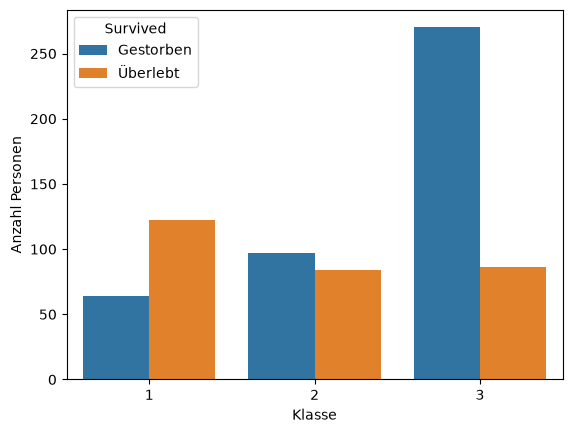

In [16]:
#Grouping Dataframe
df_copy = df.groupby(["Pclass", "Survived"], observed=False).size().reset_index(name="n")
df_copy["Survived"] = df_copy["Survived"].replace({
    0: "Gestorben",
    1: "Überlebt"
})
df_copy["Wahrscheinlichkeit"] = (
    df_copy["n"]
    / df_copy.groupby("Pclass")["n"].transform("sum")
    * 100
)

#Plotting 
sns.barplot(
    data=df_copy,
    x="Pclass",
    y="n",
    hue="Survived",
)


print(df_copy)
plt.xlabel("Klasse")
plt.ylabel("Anzahl Personen")
plt.show()

           Fare_group  Survived
0    (-0.512, 51.233]  0.331058
1   (51.233, 102.466]  0.696629
2  (102.466, 153.699]  0.714286
3  (153.699, 204.932]  1.000000
4  (204.932, 256.165]  0.777778
5  (256.165, 307.398]  0.666667
6   (307.398, 358.63]       NaN
7   (358.63, 409.863]       NaN
8  (409.863, 461.096]       NaN
9  (461.096, 512.329]  1.000000
           Fare_group  Survived      Fare  Survival_Chance
0    (-0.512, 51.233]  0.331058   25.3605        33.105802
1   (51.233, 102.466]  0.696629   76.8495        69.662921
2  (102.466, 153.699]  0.714286  128.0825        71.428571
3  (153.699, 204.932]  1.000000  179.3155       100.000000
4  (204.932, 256.165]  0.777778  230.5485        77.777778
5  (256.165, 307.398]  0.666667  281.7815        66.666667
6   (307.398, 358.63]       NaN  333.0140              NaN
7   (358.63, 409.863]       NaN  384.2465              NaN
8  (409.863, 461.096]       NaN  435.4795              NaN
9  (461.096, 512.329]  1.000000  486.7125       100.000000

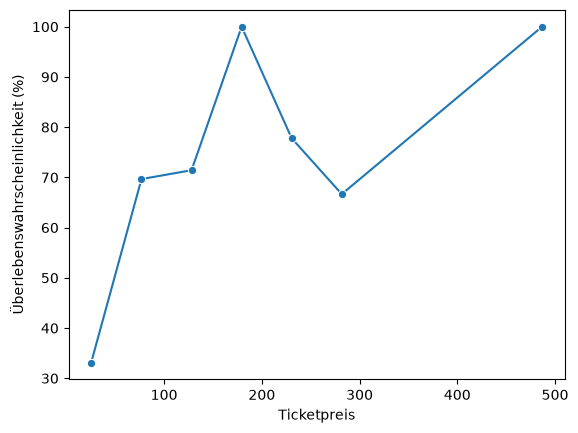

In [17]:
#10 Preisgruppen erstellen
df["Fare_group"] = pd.cut(df["Fare"], bins=10)

#Pro Preisgruppe die motralitätsrate gruppieren
survival_fare = (
    df.groupby("Fare_group", observed=False)["Survived"]
    .mean()
    .reset_index()
)
print(survival_fare)

# Mittelpunkt jedes Preisbereichs für die X-Achse
survival_fare["Fare"] = survival_fare["Fare_group"].apply(
    lambda x: x.mid
)

#Überlebenschange herausfinden
survival_fare["Survival_Chance"] = survival_fare["Survived"] * 100
print(survival_fare)

#plotting
sns.lineplot(
    data=survival_fare,
    x="Fare",
    y="Survival_Chance",
    marker="o"
)

#Label hinzufügen
plt.xlabel("Ticketpreis")
plt.ylabel("Überlebenswahrscheinlichkeit (%)")

plt.show()

  Age_group  Survived   Age  Survival_Chance
0   (0, 10]  0.593750   5.0        59.375000
1  (10, 20]  0.382609  15.0        38.260870
2  (20, 30]  0.367965  25.0        36.796537
3  (30, 40]  0.425926  35.0        42.592593
4  (40, 50]  0.383721  45.0        38.372093
5  (50, 60]  0.404762  55.0        40.476190
6  (60, 70]  0.235294  65.0        23.529412
7  (70, 80]  0.200000  75.0        20.000000


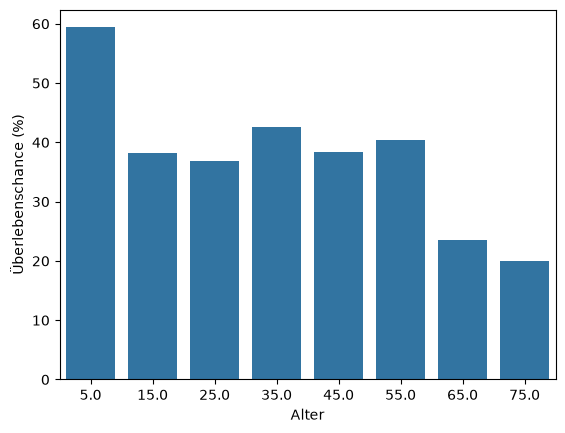

In [18]:
df_age=df
# Gruppieren in Altersklassen
df_age["Age_group"] = pd.cut(
    df["Age"],
    bins=range(0, 90, 10)
)

# Überlebenswahrscheinlichkeit pro Altersgruppe berechnen
survival_age = (
    df_age.groupby("Age_group", observed=False)["Survived"]
    .mean()
    .reset_index()
)

# Mittelpunkt der Altersgruppe
survival_age["Age"] = survival_age["Age_group"].apply(lambda x: x.mid)


survival_age["Survival_Chance"] = survival_age["Survived"] * 100

print(survival_age)

# plotting
sns.barplot(
    data=survival_age,
    x="Age",
    y="Survival_Chance",
)

plt.xlabel("Alter")
plt.ylabel("Überlebenschance (%)")

plt.show()

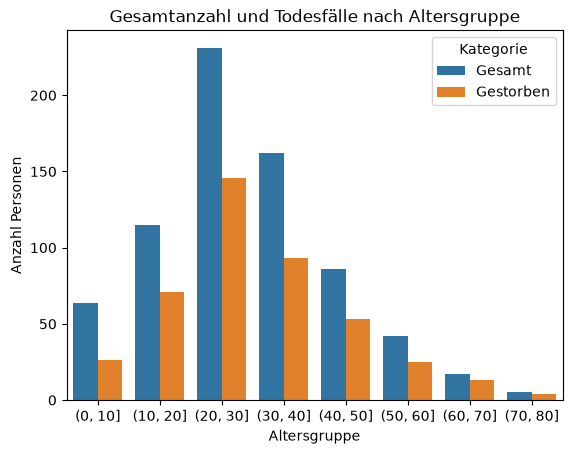

In [19]:
# Altersgruppen erstellen
df_age = df.dropna(subset=["Age"]).copy()

df_age["Age_group"] = pd.cut(
    df_age["Age"],
    bins=range(0, 90, 10)
)

# Gesamtanzahl Gäste pro Altersgruppe
total_by_age = (
    df_age.groupby("Age_group", observed=False)
    .size()
    .reset_index(name="Gesamt")
)

# Anzahl Gestorbene pro Altersgruppe
dead_by_age = (
    df_age[df_age["Survived"] == 0]
    .groupby("Age_group", observed=False)
    .size()
    .reset_index(name="Gestorben")
)

# Zusammenführen
age_stats = total_by_age.merge(
    dead_by_age,
    on="Age_group",
    how="left"
)

# Falls in einer Gruppe niemand gestorben ist
age_stats["Gestorben"] = age_stats["Gestorben"].fillna(0)

# Für Seaborn in lange Form bringen
age_plot = age_stats.melt(
    id_vars="Age_group",
    value_vars=["Gesamt", "Gestorben"],
    var_name="Kategorie",
    value_name="Anzahl"
)

age_plot["Age_group"] = age_plot["Age_group"].astype(str)

# Balkendiagramm
sns.barplot(
    data=age_plot,
    x="Age_group",
    y="Anzahl",
    hue="Kategorie"
)

plt.xlabel("Altersgruppe")
plt.ylabel("Anzahl Personen")
plt.title("Gesamtanzahl und Todesfälle nach Altersgruppe")

plt.show()

      Sex   Survived    n  Wahrscheinlichkeit
0  female  Gestorben   64           24.334601
1  female   Überlebt  199           75.665399
2    male  Gestorben  367           79.782609
3    male   Überlebt   93           20.217391


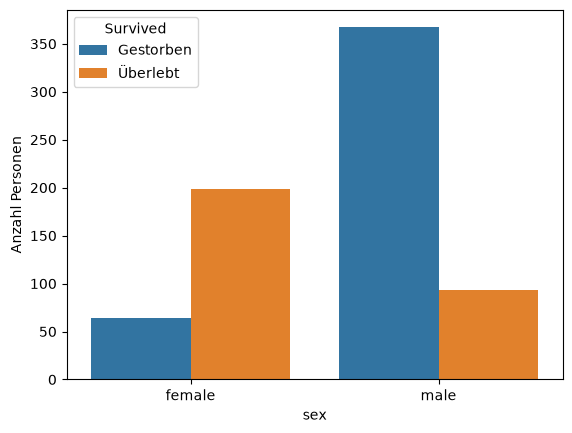

In [ ]:
#Grouping Dataframe
df_copy = df.groupby(["Sex", "Survived"], observed=False).size().reset_index(name="n")
df_copy["Survived"] = df_copy["Survived"].replace({
    0: "Gestorben",
    1: "Überlebt"
})
df_copy["Wahrscheinlichkeit"] = (
    df_copy["n"]
    / df_copy.groupby("Sex")["n"].transform("sum")
    * 100
)

#Plotting 
sns.barplot(
    data=df_copy,
    x="Sex",
    y="n",
    hue="Survived",
)


print(df_copy)
plt.xlabel("Geschlecht")
plt.ylabel("Anzahl Personen")
plt.show()